# Model Missing `resultSectionalTime`

This notebook filters out race classes flagged in the notebook notes, computes average statistics of `resultSectionalTime` based on `raceTrack`, `raceDistance`, `raceClass`  , and impute `resultSectionalTime` for the rows where it is missing.

Additionally for the races where you have no `resultSectionalTime` values at all, we add a flag `resultSectionalTime_missing` stating if it is missing.

Theses races will be treated separatly later in the modelling phase.

In [1]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

In [2]:
target_col = "resultSectionalTime"
excluded_raceclass_patterns = ["OR", "D", "HD", "HP", "IT", "IV"]

dog_infos_full = pd.read_csv("../data/intermediate/03_dog_infos_processed.csv")

raceclass_exclusion_mask = dog_infos_full["raceClass"].isna()
for pattern in excluded_raceclass_patterns:
    raceclass_exclusion_mask |= dog_infos_full["raceClass"].str.contains(pattern, na=False)

dog_infos = dog_infos_full.loc[~raceclass_exclusion_mask].copy()
dog_infos.shape

(2584672, 25)

In [3]:
observed_mask = dog_infos[target_col].notna()

# Compute the observed sectional/final ratio within stratum
ratio = dog_infos[observed_mask].groupby(
    ['trackName','raceDistance','raceClass']
).apply(lambda x: (x['resultSectionalTime'] / x['resultRunTime']).median())

# Compute global ratio for fallback
global_ratio = (dog_infos[observed_mask]['resultSectionalTime'] / dog_infos[observed_mask]['resultRunTime']).median()

# Apply ratio to missing rows
dog_infos.loc[~observed_mask, ["resultSectionalTime"]] = \
    dog_infos[~observed_mask].apply(
        lambda row: row['resultRunTime'] * ratio.get((row['trackName'], row['raceDistance'], row['raceClass']), global_ratio),
        axis=1
    )

# Reassign imputed sectional times back to the full dataframe
idx = dog_infos.index
dog_infos_full.loc[idx, ["resultSectionalTime"]] = dog_infos["resultSectionalTime"]

In [4]:
dog_infos_full['resultSectionalTime_missing'] = dog_infos_full['resultSectionalTime'].isna().astype(int)

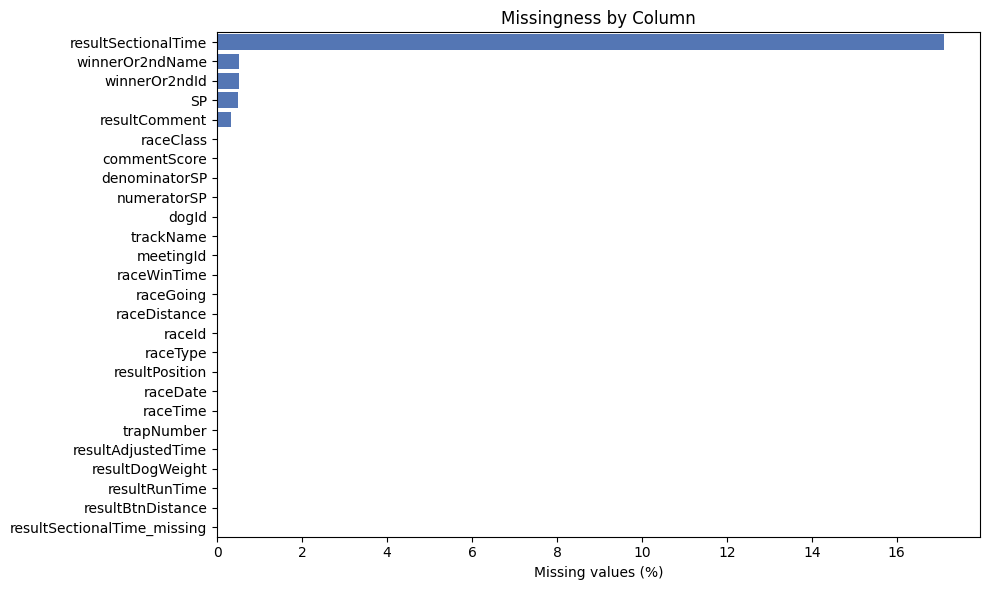

,missing_pct
resultSectionalTime,17.103632
winnerOr2ndName,0.515560
winnerOr2ndId,0.515560
SP,0.502915
resultComment,0.330620
raceClass,0.000000
commentScore,0.000000
denominatorSP,0.000000
numeratorSP,0.000000
dogId,0.000000


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

missingness = (
    dog_infos_full.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=missingness.reset_index(), x="missing_pct", y="index", color="#4472c4")
plt.title("Missingness by Column")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

missingness

Now, we have assessed all the missing data in the past dog infos dataframe. The remaining rows with missing `resultSectionalTime` will be used without it. 

In [6]:
dog_infos_full.to_csv("../data/intermediate/04_dog_infos_processed.csv", index=False)